In [3]:
!pip install plyfile

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
from plyfile import PlyData
import numpy as np
import os
import random

In [18]:
def load_ply(filepath):
    ply = PlyData.read(filepath)
    vertex = ply['vertex']
    x = np.array(vertex['x'])
    y = np.array(vertex['y'])
    z = np.array(vertex['z'])
    return np.vstack([x, y, z]).T

def extract_features(points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    spans = maxs - mins
    stds = points.std(axis=0)
    centroid = points.mean(axis=0)

    return [
        len(points),
        spans[0], spans[1], spans[2],
        stds[0], stds[1], stds[2],
        centroid[0], centroid[1], centroid[2]
    ]

In [19]:
def load_ply(filepath):
    ply = PlyData.read(filepath)
    vertex = ply['vertex']
    x = np.array(vertex['x'])
    y = np.array(vertex['y'])
    z = np.array(vertex['z'])
    return np.vstack([x, y, z]).T

def extract_features(points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    spans = maxs - mins
    stds = points.std(axis=0)
    centroid = points.mean(axis=0)

    return [
        len(points),
        spans[0], spans[1], spans[2],
        stds[0], stds[1], stds[2],
        centroid[0], centroid[1], centroid[2]
    ]

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import zipfile

zip1 = "/content/drive/MyDrive/infeasible_subset.zip"
zip2 = "/content/drive/MyDrive/feasible_subset.zip"

os.makedirs("/content/data", exist_ok=True)

for z in [zip1, zip2]:
    with zipfile.ZipFile(z, "r") as zip_ref:
        zip_ref.extractall("/content/data")

print("Done unzipping")

Done unzipping


In [22]:
ply_paths = []

for root, dirs, files in os.walk("/content/data"):
    for file in files:
        if file.endswith(".ply"):
            ply_paths.append(os.path.join(root, file))

print("Found", len(ply_paths), "PLY files")

Found 60 PLY files


In [23]:
feasible_files = [f for f in ply_paths if "feasible" in f.lower() and "infeasible" not in f.lower()]
infeasible_files = [f for f in ply_paths if "infeasible" in f.lower()]

random.shuffle(feasible_files)
random.shuffle(infeasible_files)

all_files = feasible_files[:15] + infeasible_files[:15]
random.shuffle(all_files)

print("Using", len(all_files), "files")

Using 0 files


In [24]:
for f in ply_paths[:20]:
    print(f)

/content/data/infeasiable_subset/3876.stl_pointcloud.ply
/content/data/infeasiable_subset/4343.stl_pointcloud.ply
/content/data/infeasiable_subset/4263.stl_pointcloud.ply
/content/data/infeasiable_subset/4031.stl_pointcloud.ply
/content/data/infeasiable_subset/4270.stl_pointcloud.ply
/content/data/infeasiable_subset/3841.stl_pointcloud.ply
/content/data/infeasiable_subset/4476.stl_pointcloud.ply
/content/data/infeasiable_subset/3616.stl_pointcloud.ply
/content/data/infeasiable_subset/4007.stl_pointcloud.ply
/content/data/infeasiable_subset/3914.stl_pointcloud.ply
/content/data/infeasiable_subset/4296.stl_pointcloud.ply
/content/data/infeasiable_subset/4037.stl_pointcloud.ply
/content/data/infeasiable_subset/4448.stl_pointcloud.ply
/content/data/infeasiable_subset/3726.stl_pointcloud.ply
/content/data/infeasiable_subset/4127.stl_pointcloud.ply
/content/data/infeasiable_subset/4426.stl_pointcloud.ply
/content/data/infeasiable_subset/4306.stl_pointcloud.ply
/content/data/infeasiable_subse

In [25]:
feasible_files = [f for f in ply_paths if "feasiable" in f.lower()]
infeasible_files = [f for f in ply_paths if "infeasible" in f.lower()]

In [26]:
import random

random.shuffle(feasible_files)
random.shuffle(infeasible_files)

all_files = feasible_files[:15] + infeasible_files[:15]
random.shuffle(all_files)

print("Using", len(all_files), "files")
print("Feasible:", len(feasible_files))
print("Infeasible:", len(infeasible_files))

Using 15 files
Feasible: 30
Infeasible: 0


In [27]:
for f in ply_paths[:40]:
    print(f)

/content/data/infeasiable_subset/3876.stl_pointcloud.ply
/content/data/infeasiable_subset/4343.stl_pointcloud.ply
/content/data/infeasiable_subset/4263.stl_pointcloud.ply
/content/data/infeasiable_subset/4031.stl_pointcloud.ply
/content/data/infeasiable_subset/4270.stl_pointcloud.ply
/content/data/infeasiable_subset/3841.stl_pointcloud.ply
/content/data/infeasiable_subset/4476.stl_pointcloud.ply
/content/data/infeasiable_subset/3616.stl_pointcloud.ply
/content/data/infeasiable_subset/4007.stl_pointcloud.ply
/content/data/infeasiable_subset/3914.stl_pointcloud.ply
/content/data/infeasiable_subset/4296.stl_pointcloud.ply
/content/data/infeasiable_subset/4037.stl_pointcloud.ply
/content/data/infeasiable_subset/4448.stl_pointcloud.ply
/content/data/infeasiable_subset/3726.stl_pointcloud.ply
/content/data/infeasiable_subset/4127.stl_pointcloud.ply
/content/data/infeasiable_subset/4426.stl_pointcloud.ply
/content/data/infeasiable_subset/4306.stl_pointcloud.ply
/content/data/infeasiable_subse

In [28]:
import random

feasible_files = [f for f in ply_paths if "feasable_subset" in f.lower()]
infeasible_files = [f for f in ply_paths if "infeasiable_subset" in f.lower()]

print("Feasible:", len(feasible_files))
print("Infeasible:", len(infeasible_files))

random.shuffle(feasible_files)
random.shuffle(infeasible_files)

all_files = feasible_files[:15] + infeasible_files[:15]
random.shuffle(all_files)

print("Using", len(all_files), "files")

Feasible: 30
Infeasible: 30
Using 30 files


In [29]:
X = []
y = []

for file in all_files:
    points = load_ply(file)
    X.append(extract_features(points))

    if "infeasiable_subset" in file.lower():
        y.append(0)
    else:
        y.append(1)

import numpy as np
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("Unique y:", np.unique(y, return_counts=True))

X shape: (30, 10)
Unique y: (array([0, 1]), array([15, 15]))


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train:", np.unique(y_train, return_counts=True))
print("Test:", np.unique(y_test, return_counts=True))

Train: (array([0, 1]), array([10, 11]))
Test: (array([0, 1]), array([5, 4]))


In [31]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7777777777777778
Precision: 1.0
Recall: 0.5
F1 Score: 0.6666666666666666
Confusion Matrix:
[[5 0]
 [2 2]]


In [33]:
from plyfile import PlyData
import numpy as np

def load_ply(filepath):
    ply = PlyData.read(filepath)
    vertex = ply['vertex']
    x = np.array(vertex['x'])
    y = np.array(vertex['y'])
    z = np.array(vertex['z'])
    return np.vstack([x, y, z]).T

def extract_features_augmented(points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    spans = maxs - mins
    stds = points.std(axis=0)
    centroid = points.mean(axis=0)

    dists = np.linalg.norm(points - centroid, axis=1)
    bbox_volume = spans[0] * spans[1] * spans[2]

    return [
        len(points),                 # num_points
        mins[0], mins[1], mins[2],   # min x,y,z
        maxs[0], maxs[1], maxs[2],   # max x,y,z
        spans[0], spans[1], spans[2],# span x,y,z
        stds[0], stds[1], stds[2],   # std x,y,z
        centroid[0], centroid[1], centroid[2], # centroid x,y,z
        bbox_volume,                 # bounding box volume
        dists.mean(),                # avg distance to centroid
        dists.max()                  # max distance to centroid
    ]

In [5]:
zip1 = "/content/drive/MyDrive/feasible_subset.zip"
zip2 = "/content/drive/MyDrive/infeasible_subset.zip"

In [6]:
import zipfile
import os

os.makedirs("/content/data", exist_ok=True)

for z in [zip1, zip2]:
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall("/content/data")

print("Done unzipping")

Done unzipping


In [7]:
import os

ply_paths = []
for root, dirs, files in os.walk("/content/data"):
    for file in files:
        if file.endswith(".ply"):
            ply_paths.append(os.path.join(root, file))

print("Found:", len(ply_paths))
print(ply_paths[:5])

Found: 60
['/content/data/infeasiable_subset/3876.stl_pointcloud.ply', '/content/data/infeasiable_subset/4343.stl_pointcloud.ply', '/content/data/infeasiable_subset/4263.stl_pointcloud.ply', '/content/data/infeasiable_subset/4031.stl_pointcloud.ply', '/content/data/infeasiable_subset/4270.stl_pointcloud.ply']


In [8]:
all_files = ply_paths[:100]  # keep it fast
print("Using", len(all_files), "files")

Using 60 files


In [9]:
from plyfile import PlyData
import numpy as np

def load_ply(filepath):
    ply = PlyData.read(filepath)
    vertex = ply['vertex']
    x = np.array(vertex['x'])
    y = np.array(vertex['y'])
    z = np.array(vertex['z'])
    return np.vstack([x, y, z]).T

def extract_features(points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    spans = maxs - mins
    stds = points.std(axis=0)
    centroid = points.mean(axis=0)

    return [
        len(points),
        spans[0], spans[1], spans[2],
        stds[0], stds[1], stds[2],
        centroid[0], centroid[1], centroid[2]
    ]

In [34]:
X_aug = []
y_aug = []

for file in all_files:
    points = load_ply(file)
    X_aug.append(extract_features_augmented(points))

    if "infeasiable_subset" in file.lower():
        y_aug.append(0)
    else:
        y_aug.append(1)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("X_aug shape:", X_aug.shape)
print("Unique y:", np.unique(y_aug, return_counts=True))

X_aug shape: (30, 19)
Unique y: (array([0, 1]), array([15, 15]))


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.3, random_state=42, stratify=y_aug
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Augmented model trained.")

Augmented model trained.


In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.3333333333333333
Precision: 0.3333333333333333
Recall: 0.5
F1 Score: 0.4
Confusion Matrix:
[[1 4]
 [2 2]]


In [37]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, confusion_matrix

# use your existing datasets
# X, y = basic feature set
# X_aug, y_aug = augmented feature set

datasets = {
    "basic": (X, y),
    "augmented": (X_aug, y_aug),
}

pipeline_configs = [
    ("basic_LR", "basic", None, None, LogisticRegression(max_iter=1000)),
    ("basic_STD_LR", "basic", StandardScaler(), None, LogisticRegression(max_iter=1000)),
    ("basic_MINMAX_LR", "basic", MinMaxScaler(), None, LogisticRegression(max_iter=1000)),
    ("basic_STD_SVM", "basic", StandardScaler(), None, SVC()),
    ("basic_STD_PCA2_LR", "basic", StandardScaler(), PCA(n_components=2), LogisticRegression(max_iter=1000)),
    ("basic_STD_PCA2_SVM", "basic", StandardScaler(), PCA(n_components=2), SVC()),
    ("basic_RF", "basic", None, None, RandomForestClassifier(n_estimators=100, random_state=42)),
    ("aug_LR", "augmented", None, None, LogisticRegression(max_iter=1000)),
    ("aug_STD_SVM", "augmented", StandardScaler(), None, SVC()),
    ("aug_RF", "augmented", None, None, RandomForestClassifier(n_estimators=100, random_state=42)),
]

results = []

for name, dataset_name, scaler, reducer, clf in pipeline_configs:
    X_use, y_use = datasets[dataset_name]

    X_train, X_test, y_train, y_test = train_test_split(
        X_use, y_use, test_size=0.3, random_state=42, stratify=y_use
    )

    steps = []
    if scaler is not None:
        steps.append(("scaler", scaler))
    if reducer is not None:
        steps.append(("reducer", reducer))
    steps.append(("clf", clf))

    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Pipeline": name,
        "Dataset": dataset_name,
        "F1": f1,
        "ConfusionMatrix": cm
    })

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
print(results_df[["Pipeline", "Dataset", "F1"]])

             Pipeline    Dataset        F1
1        basic_STD_LR      basic  0.857143
0            basic_LR      basic  0.666667
4   basic_STD_PCA2_LR      basic  0.666667
3       basic_STD_SVM      basic  0.600000
2     basic_MINMAX_LR      basic  0.500000
8         aug_STD_SVM  augmented  0.500000
5  basic_STD_PCA2_SVM      basic  0.444444
7              aug_LR  augmented  0.400000
6            basic_RF      basic  0.333333
9              aug_RF  augmented  0.333333


In [38]:
best_row = results_df.iloc[0]
print("Best pipeline:", best_row["Pipeline"])
print("Best F1:", best_row["F1"])
print("Best confusion matrix:\n", best_row["ConfusionMatrix"])

Best pipeline: basic_STD_LR
Best F1: 0.8571428571428571
Best confusion matrix:
 [[5 0]
 [1 3]]


In [10]:
!pip install plyfile

In [11]:
from plyfile import PlyData
import numpy as np

In [12]:
X = []
y = []

for file in all_files:
    points = load_ply(file)
    X.append(extract_features(points))

    if "infeasible" in file.lower():
        y.append(0)
    else:
        y.append(1)

X = np.array(X)
y = np.array(y)

print(X.shape)

(60, 10)


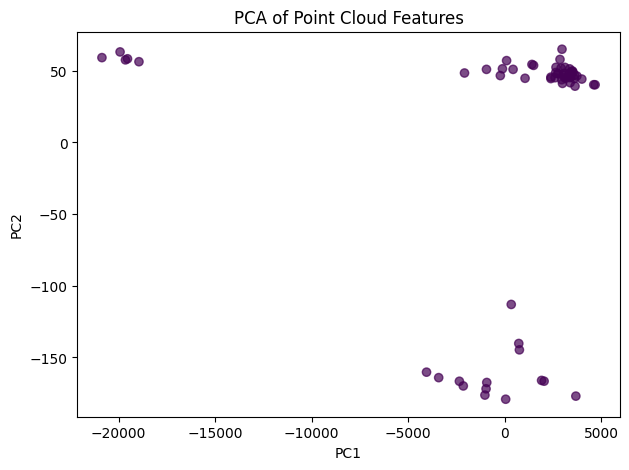

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Point Cloud Features")
plt.show()

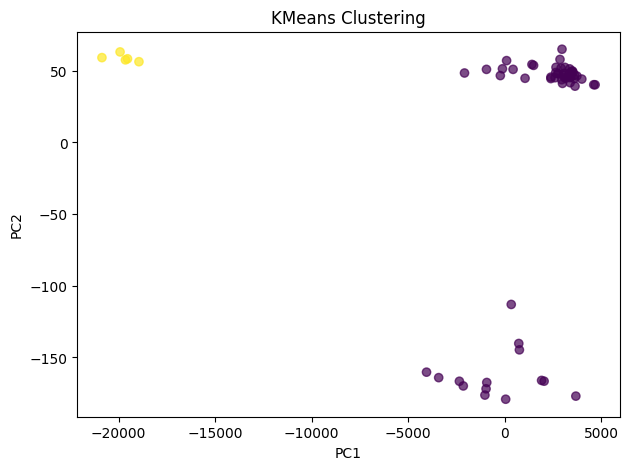

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering")
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

In [ ]:
import random

random.shuffle(ply_paths)
all_files = ply_paths[:40]   # slightly bigger = safer

In [ ]:
X = []
y = []

for file in all_files:
    points = load_ply(file)
    X.append(extract_features(points))

    if "infeasible" in file.lower():
        y.append(0)
    else:
        y.append(1)

X = np.array(X)
y = np.array(y)

print("Classes:", set(y))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

In [ ]:
import numpy as np

print("Unique y values:", np.unique(y, return_counts=True))
print("Sample file paths:")
for f in all_files[:10]:
    print(f)

In [ ]:
import random

feasible_files = [f for f in ply_paths if "feasible" in f.lower() and "infeasible" not in f.lower()]
infeasible_files = [f for f in ply_paths if "infeasible" in f.lower()]

random.shuffle(feasible_files)
random.shuffle(infeasible_files)

all_files = feasible_files[:15] + infeasible_files[:15]
random.shuffle(all_files)

print("Using", len(all_files), "files")

In [ ]:
import random

feasible_files = [f for f in ply_paths if "feasible" in f.lower() and "infeasible" not in f.lower()]
infeasible_files = [f for f in ply_paths if "infeasible" in f.lower()]

random.shuffle(feasible_files)
random.shuffle(infeasible_files)

all_files = feasible_files[:15] + infeasible_files[:15]
random.shuffle(all_files)

print("Using", len(all_files), "files")
print("Example files:")
for f in all_files[:6]:
    print(f)

In [ ]:
import os

ply_paths = []

for root, dirs, files in os.walk("/content/data"):
    for file in files:
        if file.endswith(".ply"):
            ply_paths.append(os.path.join(root, file))

print("Found", len(ply_paths), "PLY files")
print(ply_paths[:5])

In [ ]:
import os
print(os.listdir("/content"))

In [ ]:
print(os.listdir("/content/drive"))

In [ ]:
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".ply"):
            print(os.path.join(root, file))
            raise SystemExit
print("No .ply files found anywhere under /content")

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))

In [ ]:
import zipfile
import os

os.makedirs("/content/data", exist_ok=True)

In [ ]:
import zipfile
import os

zip1 = "/content/drive/MyDrive/infeasible_subset.zip"
zip2 = "/content/drive/MyDrive/feasible_subset.zip"

os.makedirs("/content/data", exist_ok=True)

for z in [zip1, zip2]:
    with zipfile.ZipFile(z, "r") as zip_ref:
        zip_ref.extractall("/content/data")

print("Done unzipping")

In [ ]:
ply_paths = []

for root, dirs, files in os.walk("/content/data"):
    for file in files:
        if file.endswith(".ply"):
            ply_paths.append(os.path.join(root, file))

print("Found", len(ply_paths), "PLY files")
print(ply_paths[:5])

In [ ]:
import random

feasible_files = [f for f in ply_paths if "feasible" in f.lower() and "infeasible" not in f.lower()]
infeasible_files = [f for f in ply_paths if "infeasible" in f.lower()]

random.shuffle(feasible_files)
random.shuffle(infeasible_files)

all_files = feasible_files[:15] + infeasible_files[:15]
random.shuffle(all_files)

print("Using", len(all_files), "files")

In [ ]:
import random

feasible_files = [f for f in ply_paths if "feasible" in f.lower() and "infeasible" not in f.lower()]
infeasible_files = [f for f in ply_paths if "infeasible" in f.lower()]

random.shuffle(feasible_files)
random.shuffle(infeasible_files)

all_files = feasible_files[:15] + infeasible_files[:15]
random.shuffle(all_files)

print("Using", len(all_files), "files")
print("Feasible sample:", len([f for f in all_files if "infeasible" not in f.lower()]))
print("Infeasible sample:", len([f for f in all_files if "infeasible" in f.lower()]))

In [ ]:
from plyfile import PlyData
import numpy as np

def load_ply(filepath):
    ply = PlyData.read(filepath)
    vertex = ply['vertex']
    x = np.array(vertex['x'])
    y = np.array(vertex['y'])
    z = np.array(vertex['z'])
    return np.vstack([x, y, z]).T

def extract_features(points):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    spans = maxs - mins
    stds = points.std(axis=0)
    centroid = points.mean(axis=0)

    return [
        len(points),
        spans[0], spans[1], spans[2],
        stds[0], stds[1], stds[2],
        centroid[0], centroid[1], centroid[2]
    ]